# Lab 11 – Kalibracja kamery i stereowizja

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

DATA  = 'Materiały-20260517/'
PAIRS = DATA + 'pairs/'
EX    = DATA + 'example/'

## 11.1 Kalibracja pojedynczej kamery

In [2]:
W, H   = 9, 6
SQUARE = 0.025
SIZE   = (640, 480)

criteria    = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
calib_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

objp = np.zeros((H * W, 1, 3), np.float64)
objp[:, 0, :2] = np.mgrid[0:W, 0:H].T.reshape(-1, 2)
objp *= SQUARE

In [3]:
def find_corners(paths, size):
    """Zwraca (objpoints, imgpoints) dla podanych ścieżek."""
    obs, ims = [], []
    det_flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
    bx, by = size[0] / 12, size[1] / 12
    for p in sorted(paths):
        gray = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2GRAY)
        ret, c = cv2.findChessboardCorners(gray, (W, H), det_flags)
        if not ret: continue
        if c[:, 0, 0].min() < bx or c[:, 0, 1].min() < by: continue
        obs.append(objp)
        ims.append(cv2.cornerSubPix(gray, c, (3, 3), (-1, -1), criteria))
    return obs, ims

obj_l, img_l = find_corners(glob.glob(PAIRS + 'left_*.png'), SIZE)
print(f'Wykryto szachownicę na {len(obj_l)} lewych obrazach')

Wykryto szachownicę na 48 lewych obrazach


In [4]:
def fisheye_calibrate(objpts, imgpts, size, flags):
    K, D = np.zeros((3, 3)), np.zeros((4, 1))
    N    = len(objpts)
    rv   = [np.zeros((1, 1, 3), np.float64) for _ in range(N)]
    tv   = [np.zeros((1, 1, 3), np.float64) for _ in range(N)]
    ret, K, D, _, _ = cv2.fisheye.calibrate(
        objpts, imgpts, size, K, D, rv, tv, flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6))
    return ret, K, D

rms, K_l, D_l = fisheye_calibrate(obj_l, img_l, SIZE, calib_flags)
print(f'RMS = {rms:.4f}')
print(f'K:\n{K_l}')
print(f'D: {D_l.T}')

RMS = 0.1146
K:
[[335.39122829   0.         345.29454256]
 [  0.         335.22281764 232.92700159]
 [  0.           0.           1.        ]]
D: [[-0.02430644 -0.01887936  0.02584275 -0.01508996]]


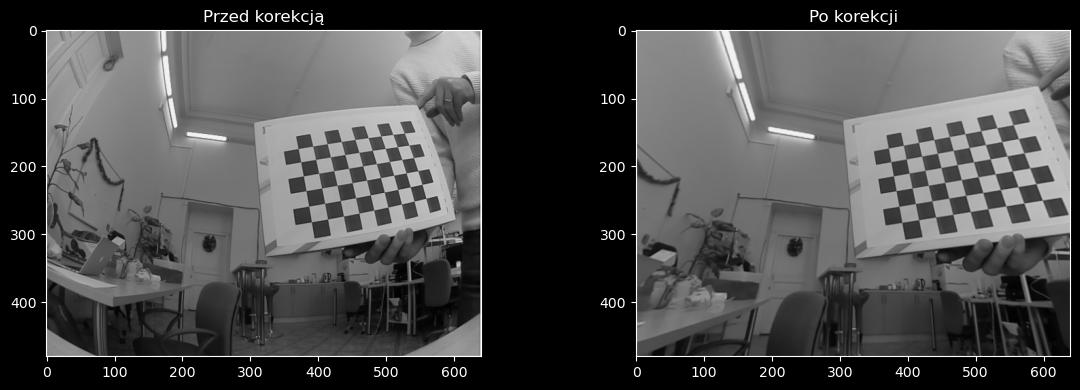

In [5]:
# Korekcja zniekształceń jednego obrazu
m1, m2 = cv2.fisheye.initUndistortRectifyMap(K_l, D_l, np.eye(3), K_l, SIZE, cv2.CV_16SC2)

raw   = cv2.imread(PAIRS + 'left_10.png')
undis = cv2.remap(raw, m1, m2, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(raw,   cv2.COLOR_BGR2RGB)); ax[0].set_title('Przed korekcją')
ax[1].imshow(cv2.cvtColor(undis, cv2.COLOR_BGR2RGB)); ax[1].set_title('Po korekcji')
plt.tight_layout(); plt.show()

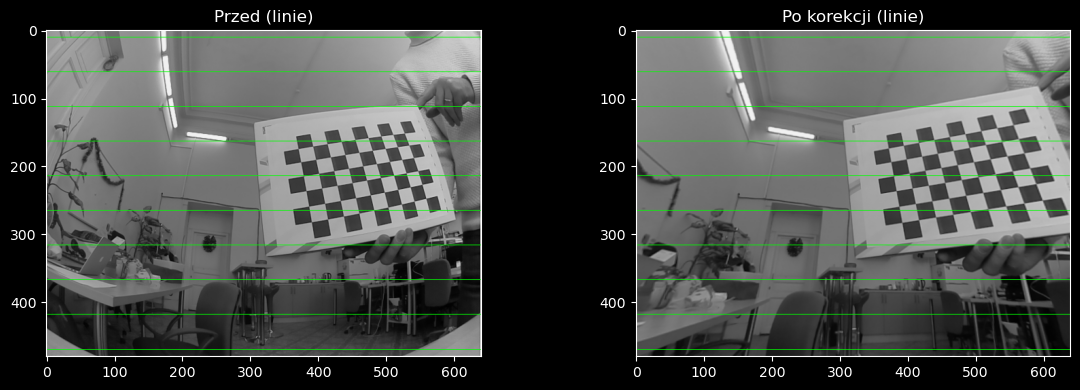

In [6]:
# Test linii prostej – linie poziome pokazują skuteczność korekcji
def hlines(img, n=10):
    out = img.copy()
    for y in np.linspace(10, img.shape[0]-10, n, dtype=int):
        cv2.line(out, (0, y), (img.shape[1], y), (0, 255, 0), 1)
    return out

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(hlines(raw),   cv2.COLOR_BGR2RGB)); ax[0].set_title('Przed (linie)')
ax[1].imshow(cv2.cvtColor(hlines(undis), cv2.COLOR_BGR2RGB)); ax[1].set_title('Po korekcji (linie)')
plt.tight_layout(); plt.show()

## 11.2 Kalibracja i rektyfikacja stereo

In [7]:
# Narożniki dla obu kamer jednocześnie (te same indeksy obrazów)
det_flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
bx, by = SIZE[0] / 12, SIZE[1] / 12
obj_s, img_ls, img_rs = [], [], []

for p_l in sorted(glob.glob(PAIRS + 'left_*.png')):
    p_r   = p_l.replace('left_', 'right_')
    gr_l  = cv2.cvtColor(cv2.imread(p_l), cv2.COLOR_BGR2GRAY)
    gr_r  = cv2.cvtColor(cv2.imread(p_r), cv2.COLOR_BGR2GRAY)
    ret_l, c_l = cv2.findChessboardCorners(gr_l, (W, H), det_flags)
    ret_r, c_r = cv2.findChessboardCorners(gr_r, (W, H), det_flags)
    if not (ret_l and ret_r): continue
    if c_l[:, 0, 0].min() < bx or c_l[:, 0, 1].min() < by: continue
    if c_r[:, 0, 0].min() < bx or c_r[:, 0, 1].min() < by: continue
    obj_s.append(objp)
    img_ls.append(cv2.cornerSubPix(gr_l, c_l, (3, 3), (-1, -1), criteria))
    img_rs.append(cv2.cornerSubPix(gr_r, c_r, (3, 3), (-1, -1), criteria))

print(f'Par stereo z szachownicą: {len(obj_s)}')

Par stereo z szachownicą: 44


In [8]:
_, K_left,  D_left  = fisheye_calibrate(obj_s, img_ls, SIZE, calib_flags)
_, K_right, D_right = fisheye_calibrate(obj_s, img_rs, SIZE, calib_flags)

rms_s, _, _, _, _, R_st, T_st = cv2.fisheye.stereoCalibrate(
    obj_s,
    np.asarray(img_ls, np.float64),
    np.asarray(img_rs, np.float64),
    K_left, D_left, K_right, D_right,
    SIZE, None, None,
    cv2.CALIB_FIX_INTRINSIC,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01))
print(f'RMS stereo: {rms_s:.4f}')

RMS stereo: 0.1443


In [9]:
R2 = np.zeros((3, 3)); P1 = np.zeros((3, 4)); P2 = np.zeros((3, 4)); Q = np.zeros((4, 4))

R1_rect, R2_rect, P1_rect, P2_rect, Q = cv2.fisheye.stereoRectify(
    K_left, D_left, K_right, D_right,
    SIZE, R_st, T_st,
    0, R2, P1, P2, Q,
    cv2.CALIB_ZERO_DISPARITY, (0, 0), 0, 0)

map1_L, map2_L = cv2.fisheye.initUndistortRectifyMap(K_left,  D_left,  R1_rect, P1_rect, SIZE, cv2.CV_16SC2)
map1_R, map2_R = cv2.fisheye.initUndistortRectifyMap(K_right, D_right, R2_rect, P2_rect, SIZE, cv2.CV_16SC2)
print('Mapy rektyfikacji gotowe')

Mapy rektyfikacji gotowe


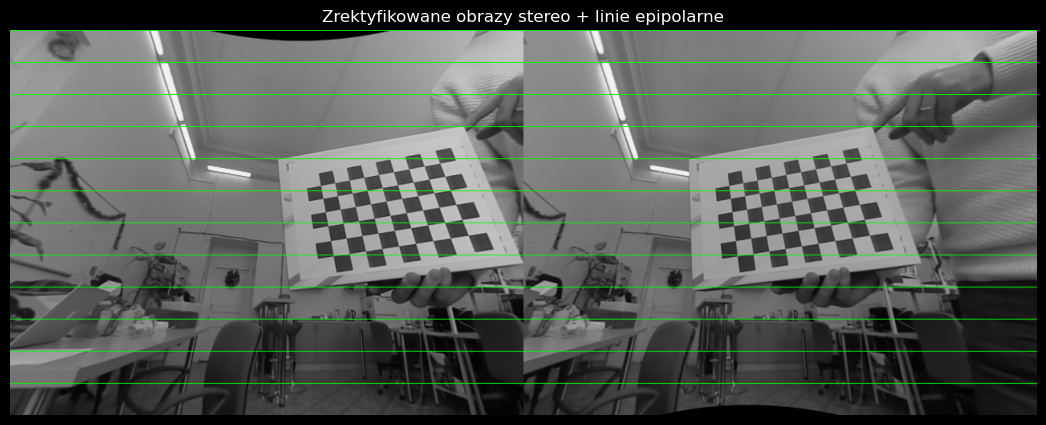

In [10]:
# Wyświetl zrektyfikowaną parę z liniami epipolarnymi
raw_l = cv2.imread(PAIRS + 'left_10.png')
raw_r = cv2.imread(PAIRS + 'right_10.png')
rect_l = cv2.remap(raw_l, map1_L, map2_L, cv2.INTER_LINEAR)
rect_r = cv2.remap(raw_r, map1_R, map2_R, cv2.INTER_LINEAR)

combined = np.hstack([rect_l, rect_r])
for y in range(0, SIZE[1], 40):
    cv2.line(combined, (0, y), (combined.shape[1], y), (0, 255, 0), 1)

plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.title('Zrektyfikowane obrazy stereo + linie epipolarne')
plt.axis('off'); plt.show()

## 11.3 Mapa dysparycji (BM i SGBM)

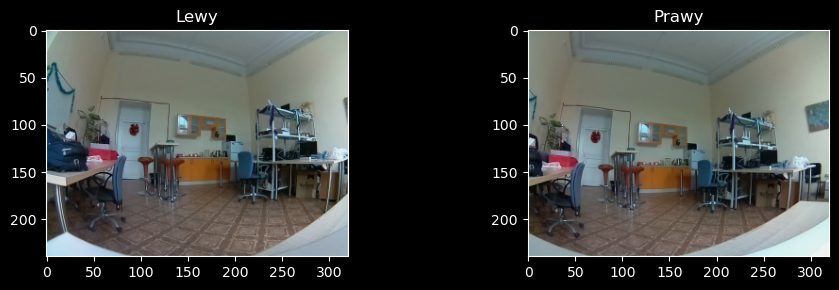

In [11]:
# Wczytaj parę example (640x240 = dwa obrazy 320x240 obok siebie)
ex   = cv2.imread(EX + 'example1.png')
ex_l = ex[:, :320]
ex_r = ex[:, 320:]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv2.cvtColor(ex_l, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lewy')
ax[1].imshow(cv2.cvtColor(ex_r, cv2.COLOR_BGR2RGB)); ax[1].set_title('Prawy')
plt.tight_layout(); plt.show()

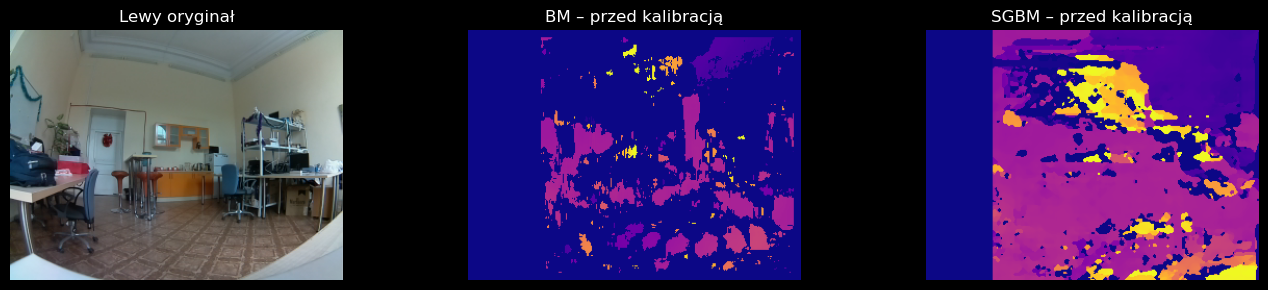

In [12]:
# Dysparycja PRZED kalibracją
g_l = cv2.cvtColor(ex_l, cv2.COLOR_BGR2GRAY)
g_r = cv2.cvtColor(ex_r, cv2.COLOR_BGR2GRAY)

bm   = cv2.StereoBM_create(numDisparities=64, blockSize=15)
sgbm = cv2.StereoSGBM_create(minDisparity=0, numDisparities=64, blockSize=7,
                              P1=8*3*49, P2=32*3*49)

d_bm   = bm.compute(g_l, g_r).astype(np.float32)   / 16.0
d_sgbm = sgbm.compute(g_l, g_r).astype(np.float32) / 16.0

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].imshow(cv2.cvtColor(ex_l, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lewy oryginał')
ax[1].imshow(d_bm,   cmap='plasma'); ax[1].set_title('BM – przed kalibracją')
ax[2].imshow(d_sgbm, cmap='plasma'); ax[2].set_title('SGBM – przed kalibracją')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

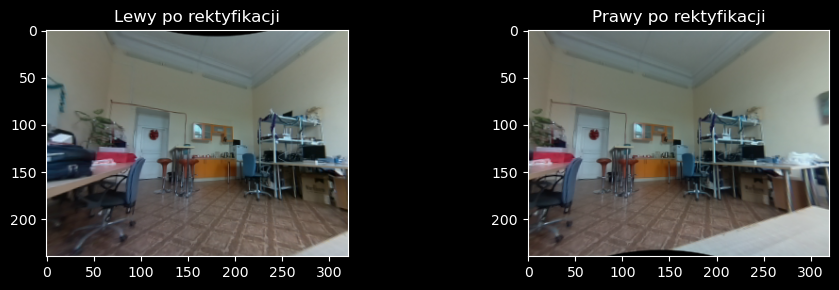

In [13]:
# Rektyfikacja obrazów example – skalowanie macierzy K do rozmiaru 320x240
EX_SIZE = (320, 240)
sx, sy  = EX_SIZE[0] / SIZE[0], EX_SIZE[1] / SIZE[1]

Kl_ex = K_left.copy();  Kl_ex[0] *= sx; Kl_ex[1] *= sy
Kr_ex = K_right.copy(); Kr_ex[0] *= sx; Kr_ex[1] *= sy

Pl_ex = P1_rect.copy(); Pl_ex[0] *= sx; Pl_ex[1] *= sy
Pr_ex = P2_rect.copy(); Pr_ex[0] *= sx; Pr_ex[1] *= sy

m1l, m2l = cv2.fisheye.initUndistortRectifyMap(Kl_ex, D_left,  R1_rect, Pl_ex[:3, :3], EX_SIZE, cv2.CV_16SC2)
m1r, m2r = cv2.fisheye.initUndistortRectifyMap(Kr_ex, D_right, R2_rect, Pr_ex[:3, :3], EX_SIZE, cv2.CV_16SC2)

rect_el = cv2.remap(ex_l, m1l, m2l, cv2.INTER_LINEAR)
rect_er = cv2.remap(ex_r, m1r, m2r, cv2.INTER_LINEAR)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv2.cvtColor(rect_el, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lewy po rektyfikacji')
ax[1].imshow(cv2.cvtColor(rect_er, cv2.COLOR_BGR2RGB)); ax[1].set_title('Prawy po rektyfikacji')
plt.tight_layout(); plt.show()

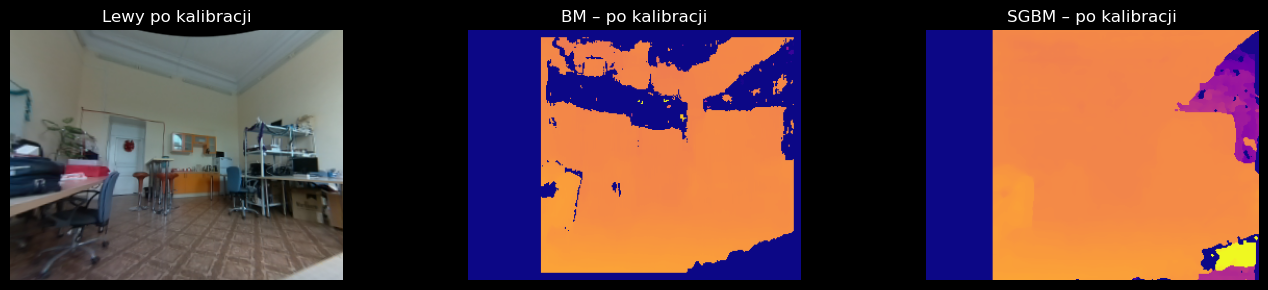

In [14]:
# Dysparycja PO kalibracji
gr_l = cv2.cvtColor(rect_el, cv2.COLOR_BGR2GRAY)
gr_r = cv2.cvtColor(rect_er, cv2.COLOR_BGR2GRAY)

d_bm_cal   = bm.compute(gr_l, gr_r).astype(np.float32)   / 16.0
d_sgbm_cal = sgbm.compute(gr_l, gr_r).astype(np.float32) / 16.0

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].imshow(cv2.cvtColor(rect_el, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lewy po kalibracji')
ax[1].imshow(d_bm_cal,   cmap='plasma'); ax[1].set_title('BM – po kalibracji')
ax[2].imshow(d_sgbm_cal, cmap='plasma'); ax[2].set_title('SGBM – po kalibracji')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

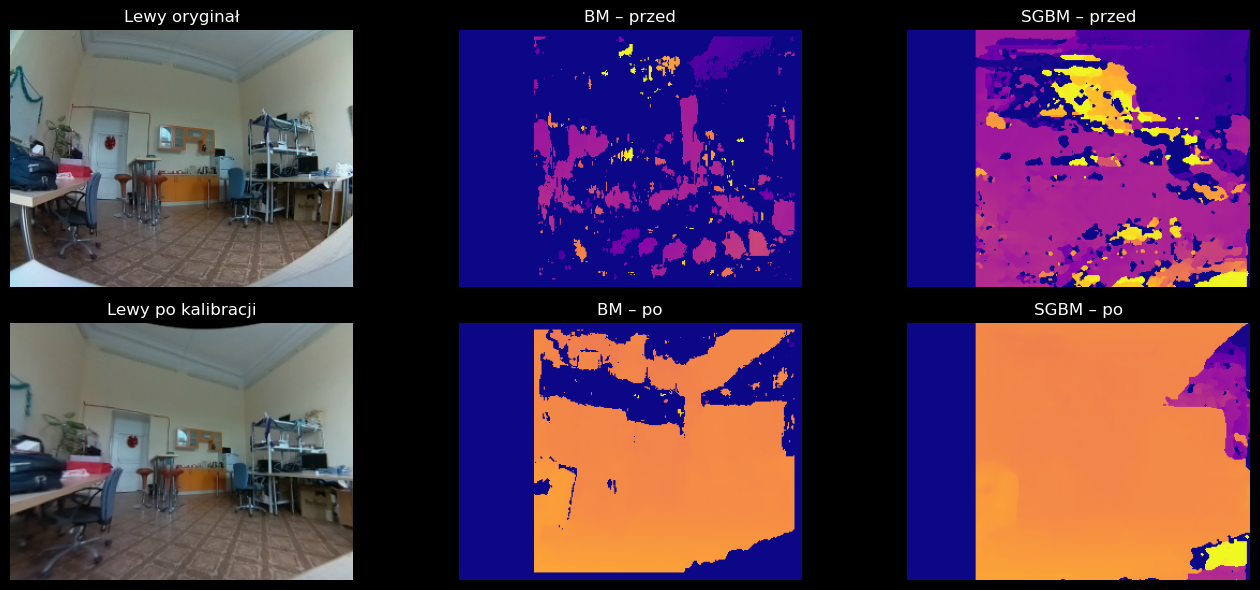

In [15]:
# Zbiorcze porównanie przed vs po
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
ax[0,0].imshow(cv2.cvtColor(ex_l,    cv2.COLOR_BGR2RGB)); ax[0,0].set_title('Lewy oryginał')
ax[0,1].imshow(d_bm,   cmap='plasma'); ax[0,1].set_title('BM – przed')
ax[0,2].imshow(d_sgbm, cmap='plasma'); ax[0,2].set_title('SGBM – przed')
ax[1,0].imshow(cv2.cvtColor(rect_el, cv2.COLOR_BGR2RGB)); ax[1,0].set_title('Lewy po kalibracji')
ax[1,1].imshow(d_bm_cal,   cmap='plasma'); ax[1,1].set_title('BM – po')
ax[1,2].imshow(d_sgbm_cal, cmap='plasma'); ax[1,2].set_title('SGBM – po')
for a in ax.flat: a.axis('off')
plt.tight_layout(); plt.show()